<a href="https://colab.research.google.com/github/dimasrhesky270206/Pcvk_SEMESTER-5/blob/main/pertemuan_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PRATIKUM
D1.OPERASI CITRA SEDERHANA

In [1]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 80


/tmp/ipykernel_1587/148336234.py:17: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


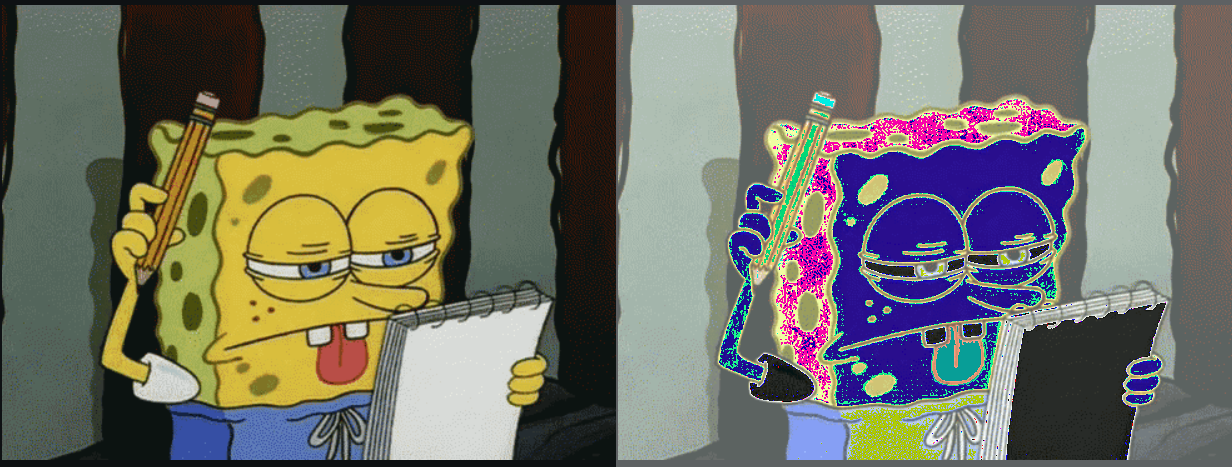

In [3]:
print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/pcvk/kartun.png')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

TUGAS PRATIKUM

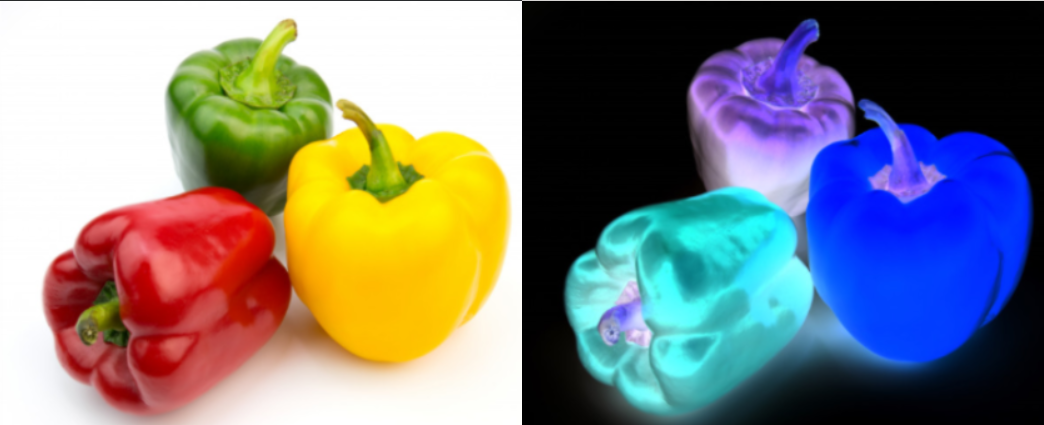

In [6]:
# Modul Inverse Citra (Citra Negatif)
original = cv.imread('/content/drive/MyDrive/pcvk/paprika.png')
inverse_image = np.zeros(original.shape, original.dtype)

# Akses per piksel menggunakan formula: g(x,y) = 255 - f(x,y)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            inverse_image[y, x, c] = 255 - original[y, x, c]

# Cara simple tanpa loop (operasi matriks NumPy)
# inverse_image = 255 - original

final_frame = cv.hconcat((original, inverse_image))
cv2_imshow(final_frame)

IMPLEMENTASI CONTRAS


Mengubah kontras dan tingkat kecerahan citra
Masukkan tingkat kecerahan: 10
Masukkan kontras: 1.5


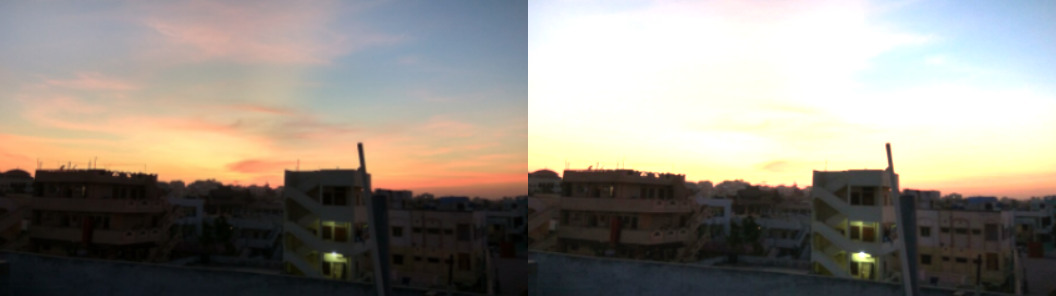

In [8]:
print('Mengubah kontras dan tingkat kecerahan citra')
try:
    brightness = int(input('Masukkan tingkat kecerahan: '))
    contrast = float(input('Masukkan kontras: '))
except ValueError:
    print('Error, not a number')

img = cv.imread('/content/drive/MyDrive/pcvk/Screenshot 2026-09-17 222949.png')
contrast_img = np.zeros(img.shape, img.dtype)

# Menghitung contrast & brightness
for y in range(img.shape[0]):
    for x in range(img.shape[1]):
        for c in range(img.shape[2]):
            contrast_img[y, x, c] = np.clip(contrast * img[y, x, c] + brightness, 0, 255)

final = cv.hconcat((img, contrast_img))
cv2_imshow(final)

IMPLEMENTASI LOGARITMIC BRIGTHNES

Mengubah tingkat kecerahan citra dengan Transformasi Log
Masukkan nilai kecerahan / konstanta: 40


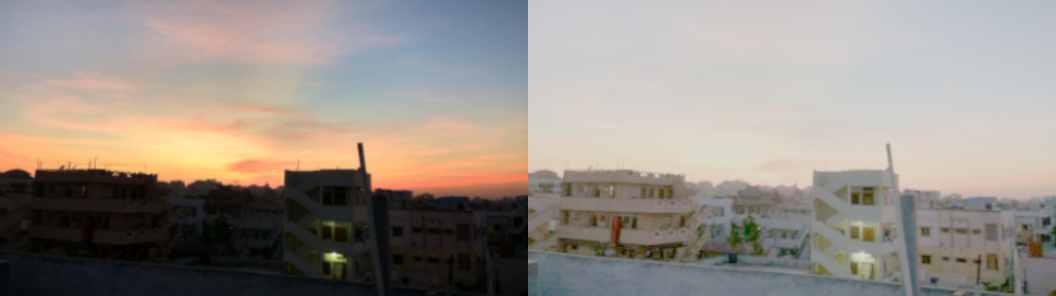

In [10]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
try:
    c_val = float(input('Masukkan nilai kecerahan / konstanta: '))
except ValueError:
    print('Error, not a number')

img = cv.imread('/content/drive/MyDrive/pcvk/Screenshot 2026-09-17 222949.png')

# Konversi citra ke float untuk perhitungan logaritma
img_float = img.astype(np.float32)

# Rumus Logarithmic Transformation: s = c * log(1 + r)
# Menggunakan log1p (log(1 + x))
c = 255 / np.log(1 + np.max(img_float)) if c_val == 0 else c_val
log_img = c * np.log1p(img_float)
log_img = np.clip(log_img, 0, 255).astype(np.uint8)

final = cv.hconcat((img, log_img))
cv2_imshow(final)

IMPLEMENTASI GRAYSCALE

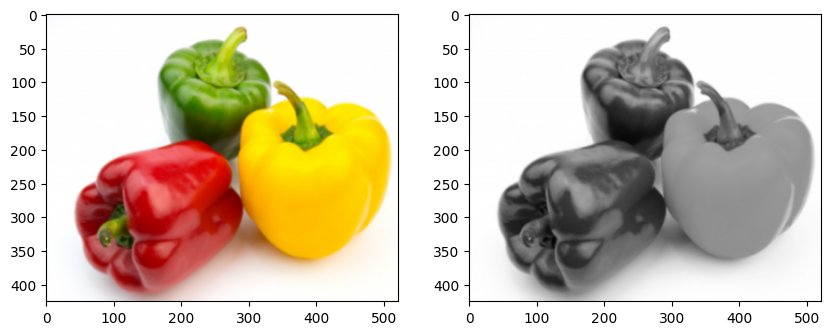

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/pcvk/paprika.png')
gray_avg = np.zeros((original.shape[0], original.shape[1]), dtype=np.uint8)

# Rumus Averaging: (R + G + B) / 3
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b, g, r = original[y, x]
        gray_avg[y, x] = np.clip((int(r) + int(g) + int(b)) / 3, 0, 255)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.subplot(1, 2, 2); plt.imshow(gray_avg, cmap='gray')
plt.show()

/tmp/ipykernel_1587/85377309.py:12: RuntimeWarning: overflow encountered in scalar add
  gray_lightness[y, x] = np.clip((max(r, g, b) + min(r, g, b)) / 2, 0, 255)


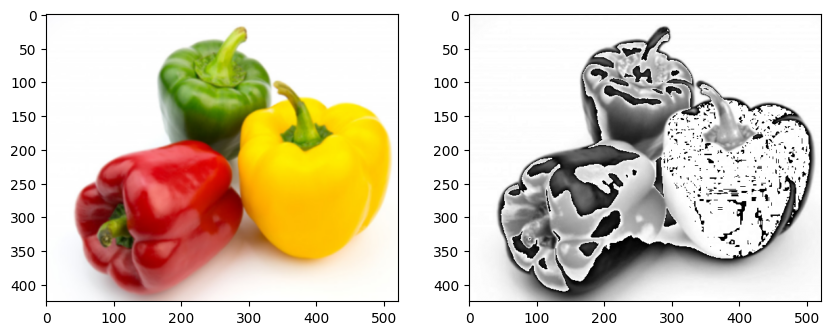

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/pcvk/paprika.png')
gray_lightness = np.zeros((original.shape[0], original.shape[1]), dtype=np.uint8)

# Rumus Lightness: (max(R, G, B) + min(R, G, B)) / 2
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b, g, r = original[y, x]
        gray_lightness[y, x] = np.clip((max(r, g, b) + min(r, g, b)) / 2, 0, 255)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.subplot(1, 2, 2); plt.imshow(gray_lightness, cmap='gray')
plt.show()

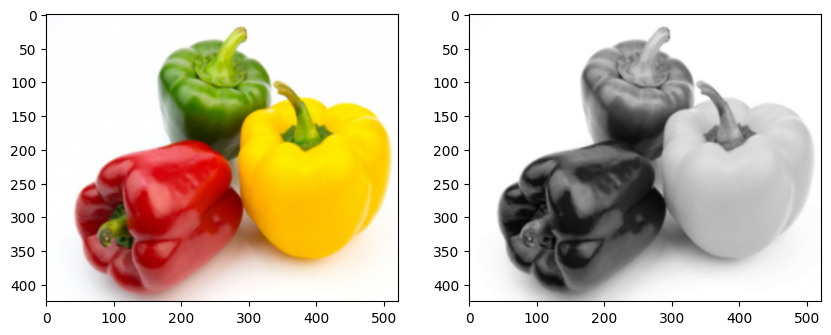

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/pcvk/paprika.png')
gray_luminance = np.zeros((original.shape[0], original.shape[1]), dtype=np.uint8)

# Rumus Luminance: 0.21*R + 0.72*G + 0.07*B
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b, g, r = original[y, x]
        gray_luminance[y, x] = np.clip(0.21 * r + 0.72 * g + 0.07 * b, 0, 255)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.subplot(1, 2, 2); plt.imshow(gray_luminance, cmap='gray')
plt.show()

Tampilkanlah warna tertentu pada citra

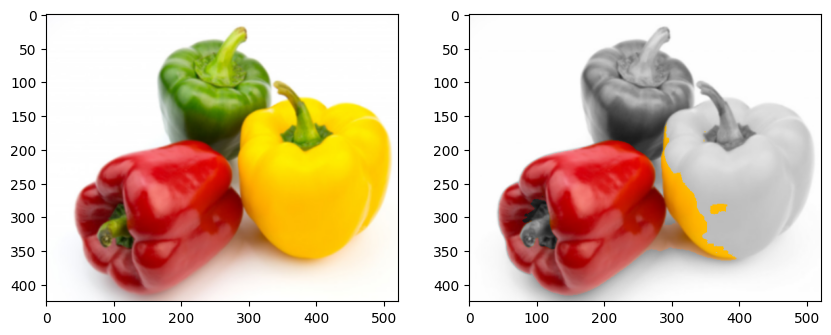

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/pcvk/paprika.png')
result = np.zeros(original.shape, original.dtype)

# Menyeleksi MURNI warna merah
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b, g, r = int(original[y, x][0]), int(original[y, x][1]), int(original[y, x][2])

        # Kondisi ketat agar warna kuning (R tinggi + G tinggi) tidak ikut lolos
        if r > 100 and r > (g * 1.35) and r > (b * 1.35):
            result[y, x] = original[y, x]  # Tetap tampilkan warna asli
        else:
            gray = int(0.21 * r + 0.72 * g + 0.07 * b)
            result[y, x] = [gray, gray, gray]  # Ubah ke grayscale

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.show()